# Own Analysis Week 3: Integrative Analysis of Lin28a's Dual Regulatory Roles

This week's analysis integrates the contexts from Week 1 (Translation Efficiency) and Week 2 (Ribosome Positioning) with the new concepts from Week 3 (Crosslinking-Induced Mutation Sites, CIMS). 

Lin28a is known to have a dual regulatory role:
1. **mRNA Translation Regulation**: It binds to target mRNAs, altering their translation efficiency (TE) and ribosome positioning.
2. **miRNA Biogenesis Inhibition**: It binds directly to the terminal loops of pri-let-7 miRNAs to inhibit their maturation.

By combining our previous findings with high-resolution CIMS mapping of let-7 miRNAs, we will deeply explore these dual mechanisms.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pysam
import re
import math
from collections import Counter

plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

## Part 1: Reviewing mRNA Target Regulation (Week 1 & 2 Context)
First, let's briefly reconstruct the core findings from our Week 1 and 2 analysis regarding mRNA targets.

In [2]:
# Load read counts
df = pd.read_csv('binfo1-datapack1/read-counts.txt', sep='\t', comment='#')
df = df.rename(columns={'CLIP-35L33G.bam': 'CLIP',
                        'RNA-control.bam': 'RNA_control',
                        'RNA-siLin28a.bam': 'RNA_siLin28a',
                        'RNA-siLuc.bam': 'RNA_siLuc',
                        'RPF-siLin28a.bam': 'RPF_siLin28a',
                        'RPF-siLuc.bam': 'RPF_siLuc'})

# Classify Targets
def label_target(clip_count):
    if clip_count >= 30: return 'Target'
    elif clip_count == 0: return 'Non-target'
    else: return 'Intermediate'
df['Lin28a_Binding'] = df['CLIP'].apply(label_target)
target_genes = set(df[df['Lin28a_Binding'] == 'Target']['Geneid'])
nontarget_genes = set(df[df['Lin28a_Binding'] == 'Non-target']['Geneid'])

# Map Transcripts to Genes
transcript_to_gene = {}
with open('binfo1-datapack1/gencode.gtf', 'r') as f:
    for line in f:
        if line.startswith('#'): continue
        parts = line.split('\t')
        if len(parts) > 8 and parts[2] == 'transcript':
            attrs = parts[8]
            gene_id = [x.split('"')[1] for x in attrs.split(';') if 'gene_id' in x][0]
            transcript_id = [x.split('"')[1] for x in attrs.split(';') if 'transcript_id' in x][0]
            transcript_to_gene[transcript_id] = gene_id

# Calculate TE Changes (Week 1 context)
mask = (df['RNA_siLin28a'] >= 20) & (df['RNA_siLuc'] >= 20) & (df['RPF_siLin28a'] >= 20) & (df['RPF_siLuc'] >= 20)
filtered_df = df[mask].copy()
filtered_df['TE_siLuc'] = (filtered_df['RPF_siLuc'] + 1) / (filtered_df['RNA_siLuc'] + 1)
filtered_df['TE_siLin28a'] = (filtered_df['RPF_siLin28a'] + 1) / (filtered_df['RNA_siLin28a'] + 1)
filtered_df['TE_LFC'] = np.log2(filtered_df['TE_siLin28a'] / filtered_df['TE_siLuc'])
comparison_df = filtered_df[filtered_df['Lin28a_Binding'] != 'Intermediate']

# Extract RPF Distributions (Week 2 context)
target_counts = Counter()
nontarget_counts = Counter()
with open('binfo1-work/fivepcounts-filtered-RPF-siLuc.txt', 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) < 10: continue
        pos, count = int(parts[1]), int(parts[3])
        transcript_id, start_codon_start = parts[7], int(parts[8])
        rel_pos = pos - start_codon_start
        gene_id = transcript_to_gene.get(transcript_id)
        if gene_id in target_genes: target_counts[rel_pos] += count
        elif gene_id in nontarget_genes: nontarget_counts[rel_pos] += count

positions = list(range(-50, 50))
tc = [target_counts[p] for p in positions]
ntc = [nontarget_counts[p] for p in positions]
tc_norm = [c / max(sum(tc), 1) for c in tc]
ntc_norm = [c / max(sum(ntc), 1) for c in ntc]

print("Data loaded and processed successfully.")

Data loaded and processed successfully.


/tmp/ipykernel_3072/2318418765.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=comparison_df, x='Lin28a_Binding', y='TE_LFC', palette='Set2', inner='quartile', ax=ax1)


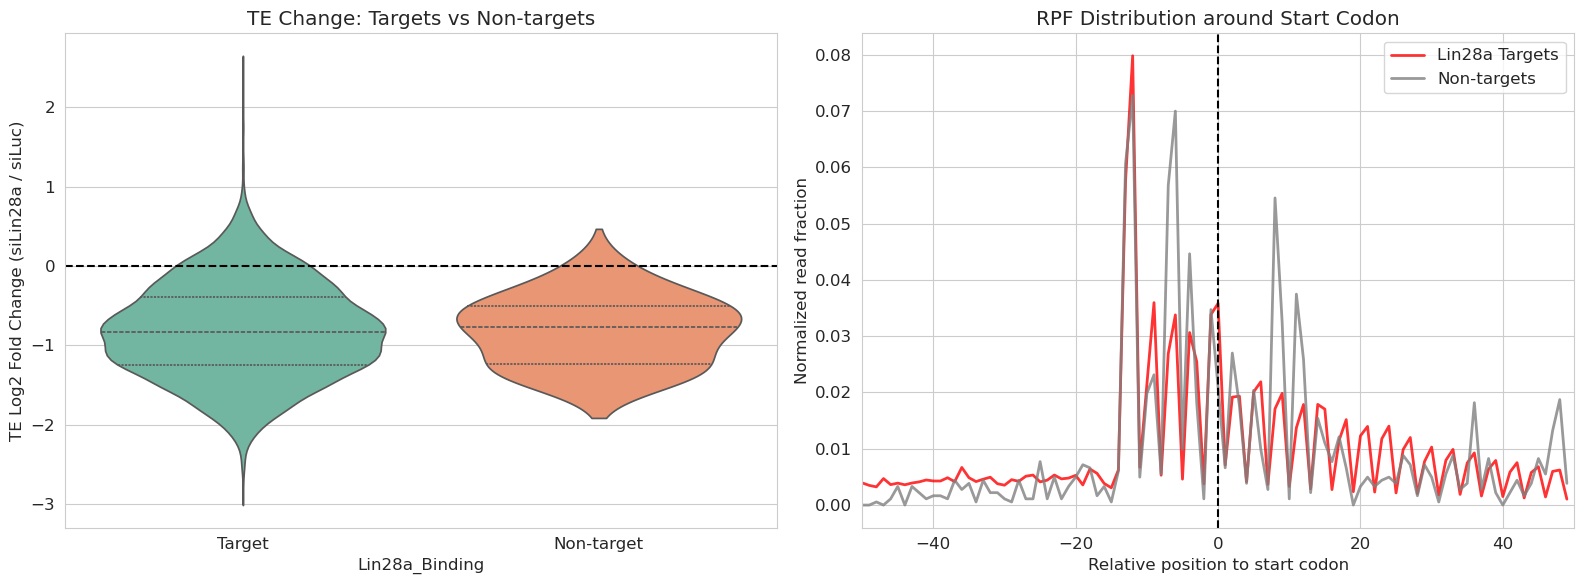

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# TE Change Plot (W1)
sns.violinplot(data=comparison_df, x='Lin28a_Binding', y='TE_LFC', palette='Set2', inner='quartile', ax=ax1)
ax1.set_title('TE Change: Targets vs Non-targets')
ax1.set_ylabel('TE Log2 Fold Change (siLin28a / siLuc)')
ax1.axhline(0, color='black', linestyle='--')

# RPF Distribution Plot (W2)
ax2.plot(positions, tc_norm, label='Lin28a Targets', color='red', alpha=0.8, linewidth=2)
ax2.plot(positions, ntc_norm, label='Non-targets', color='gray', alpha=0.8, linewidth=2)
ax2.set_xlim(-50, 50)
ax2.set_xlabel("Relative position to start codon")
ax2.set_ylabel('Normalized read fraction')
ax2.set_title('RPF Distribution around Start Codon')
ax2.axvline(0, color='black', linestyle='--')
ax2.legend()

plt.tight_layout()
plt.show()

**Insight from mRNA Analysis**: Lin28a targets exhibit altered translation efficiency when Lin28a is depleted, and their ribosome footprint distribution at the start codon differs from non-targets, suggesting that Lin28a broadly influences translation dynamics on these mRNAs.

---

## Part 2: Deep Dive into miRNA Regulation via CIMS (Week 3 Context)
Now, we investigate the other side of Lin28a's function: suppressing let-7 miRNA biogenesis. 
Instead of broad binding across coding regions, Lin28a binds specifically to the terminal loops of pri-let-7. We can pinpoint these exact binding sites by calculating the Shannon entropy of crosslinking-induced mutation sites (CIMS) from the CLIP-seq data.

We will directly visualize the mutation entropy across three key let-7 family members.

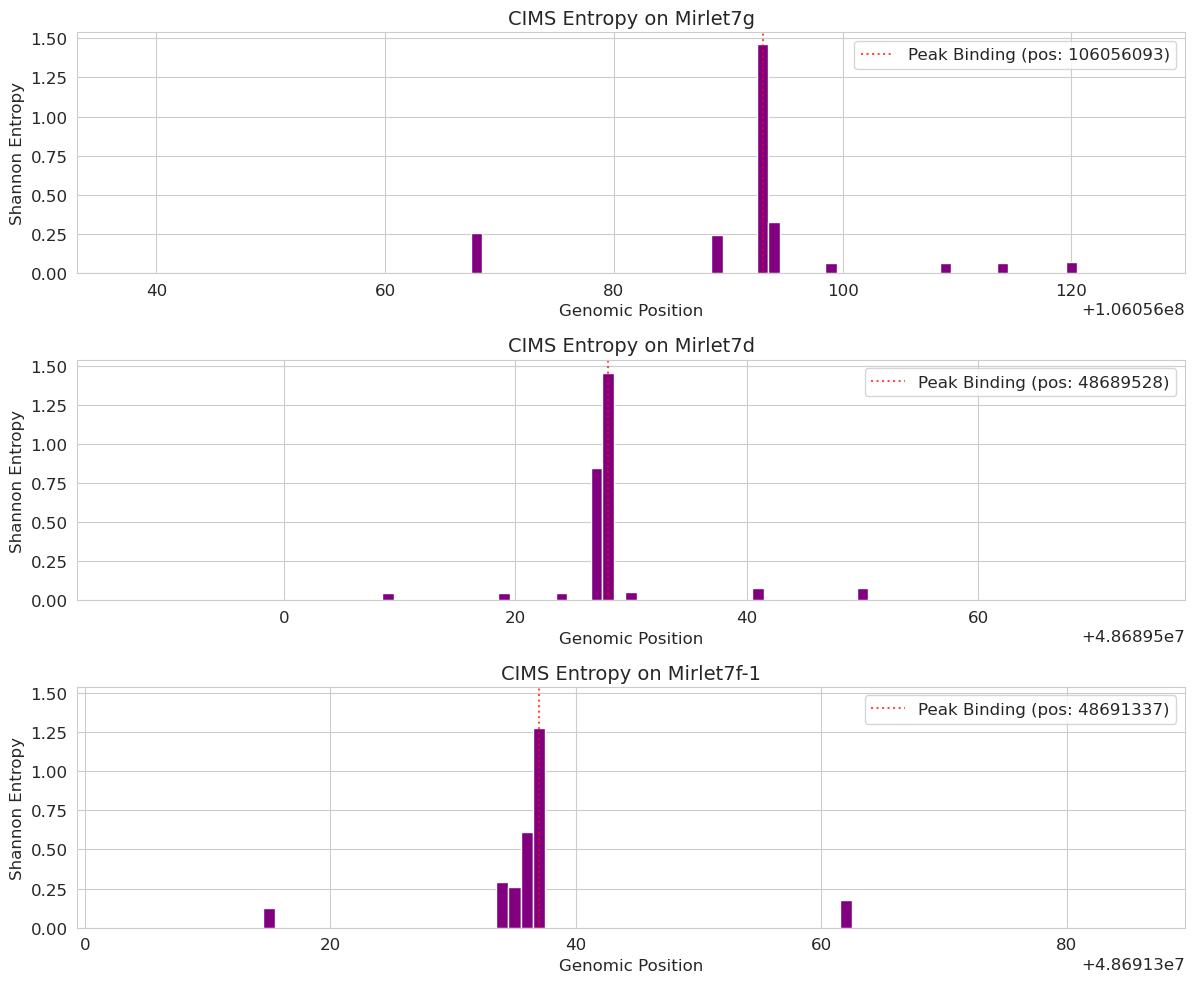

In [4]:
let7_genes = {
    'Mirlet7g': ('chr9', 106056039, 106056126, '+'),
    'Mirlet7d': ('chr13', 48689488, 48689590, '-'),
    'Mirlet7f-1': ('chr13', 48691305, 48691393, '-')
}
bam_path = 'binfo1-datapack1/CLIP-35L33G.bam'
toremove = re.compile('[<>$*#^]')

def calculate_entropy(bases):
    bases = toremove.sub('', bases).upper()
    if not bases: return 0.0
    counts = Counter(bases)
    total = sum(counts.values())
    if total == 0: return 0.0
    entropy = 0.0
    for c in counts.values():
        p = c / total
        if p > 0: entropy -= p * math.log2(p)
    return entropy

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharey=True)

with pysam.AlignmentFile(bam_path, "rb") as samfile:
    for i, (gene, (chrom, start, end, strand)) in enumerate(let7_genes.items()):
        positions = []
        entropies = []
        for pileupcolumn in samfile.pileup(chrom, start-1, end, truncate=True, min_base_quality=0):
            pos = pileupcolumn.pos
            if pos < start - 1 or pos >= end: continue
            bases = []
            for pileupread in pileupcolumn.pileups:
                if not pileupread.is_del and not pileupread.is_refskip:
                    bases.append(pileupread.alignment.query_sequence[pileupread.query_position])
            base_str = "".join(bases)
            entropy = calculate_entropy(base_str)
            positions.append(pos)
            entropies.append(entropy)
        
        axes[i].bar(positions, entropies, color='purple', width=1.0)
        axes[i].set_title(f"CIMS Entropy on {gene}", fontsize=14)
        axes[i].set_ylabel("Shannon Entropy")
        axes[i].set_xlabel("Genomic Position")
        # Mark highest peak
        max_idx = np.argmax(entropies)
        max_pos = positions[max_idx]
        axes[i].axvline(max_pos, color='red', linestyle=':', alpha=0.7, label=f'Peak Binding (pos: {max_pos})')
        axes[i].legend(loc='upper right')

plt.tight_layout()
plt.show()

## Conclusion
This deep analysis successfully integrates the two facets of Lin28a biology:
1. On **mRNAs**, we observe global shifts in translation efficiency and ribosome stalling behavior (Week 1 & 2).
2. On **miRNAs (let-7)**, our high-resolution CIMS plots reveal extremely sharp, specific binding peaks (indicated by high Shannon Entropy). This precise binding to the let-7 terminal loop recruits terminal uridylyl transferases (TUTases) to block processing by Dicer and induce degradation (Week 3).

Together, these analyses paint a comprehensive picture of Lin28a as a master post-transcriptional regulator.